In [5]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import copy
import spectroscopic_efficiency

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


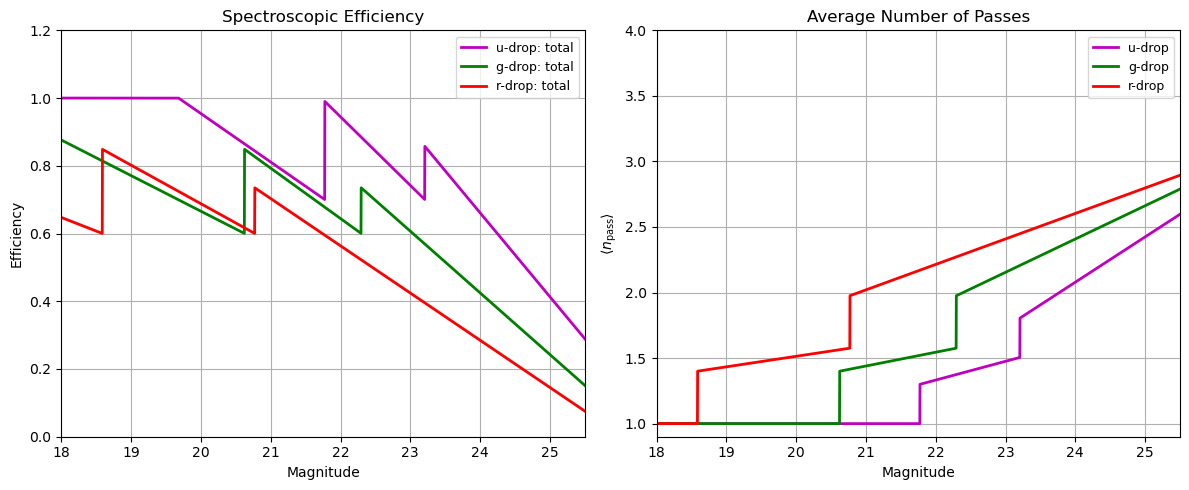

In [7]:
# Magnitude range
m_vals = np.linspace(18., 28, 3400)

colors = ['m', 'g', 'r']
p_min_list = [0.7, 0.6, 0.6]
z_eff = [3, 4, 5]
Dz = [6, 7, 8]
dropout_bands = ['u', 'g', 'r']
plateau=1

# Create a single figure with 2 subplots
fig, (ax_eff, ax_pass) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

for i, dropout_band in enumerate(dropout_bands):

    p_min = p_min_list[i]

    # Compute efficiencies and average number of passes
    #E_vals = spectroscopic_efficiency.E_wst_lbg_dropout_piecewise_wdassignies(z_eff[i], m_vals,  p_min=p_min, plateau=plateau, dropout_band = dropout_band)
    
    #
    #n_vals = spectroscopic_efficiency.n_pass_wst_lbg_dropout_piecewise_wdassignies(z_eff[i], m_vals, p_min=p_min, plateau=plateau, dropout_band = dropout_band)

    #ax_eff.plot(m_vals,spectroscopic_efficiency.E_wst_lbg_dropout(z_eff[i], m_vals, dropout_band = dropout_band),'--' + colors[i],label=f'{dropout_band}-drop: single exp')

    #ax_eff.plot(m_vals,E_vals,colors[i],lw=2,label=f'{dropout_band}-drop: total')
    #ax_pass.plot(m_vals,n_vals,color=colors[i],lw=2,label=f'{dropout_band}-drop')

    E_vals = spectroscopic_efficiency.E_wst_lbg_dropout_piecewise(z_eff[i], m_vals,  p_min=p_min, plateau=plateau, dropout_band = dropout_band)
    n_vals = spectroscopic_efficiency.n_pass_wst_lbg_dropout_piecewise(z_eff[i], m_vals, p_min=p_min, plateau=plateau, dropout_band = dropout_band)

    ax_eff.plot(m_vals,E_vals,'-'+colors[i],lw=2,label=f'{dropout_band}-drop: total')
    ax_pass.plot(m_vals,n_vals,'-'+colors[i],lw=2,label=f'{dropout_band}-drop')

ax_eff.set_title("Spectroscopic Efficiency")
ax_eff.set_xlabel("Magnitude")
ax_eff.set_ylabel("Efficiency")
ax_eff.set_xlim(18, 25.5)
ax_eff.set_ylim(0, 1.2)
ax_eff.grid(True)
ax_eff.legend(fontsize=9)

ax_pass.set_title("Average Number of Passes")
ax_pass.set_xlabel("Magnitude")
ax_pass.set_ylabel(r"$\langle n_{\rm pass} \rangle$")
ax_pass.set_xlim(18, 25.5)
ax_pass.set_ylim(0.9, 4)
ax_pass.grid(True)
ax_pass.legend(fontsize=9)

plt.tight_layout()

#plt.savefig(
#    '../figures/spectroscopic_efficiency_all_LBG_dropout.png',
#    dpi=300,
#    bbox_inches='tight'
#)

plt.show()

In [3]:
N_zm_u = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_udropout_highz.npz')
N_zm_g = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_gdropout.npz')
N_zm_r = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_rdropout.npz')
samples = [N_zm_u, N_zm_g, N_zm_r]

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Magnitude range
m_vals = np.linspace(19., 26, 340)

color = ['m', 'g', 'r']

mag_max = [25,25,25]
Dz = [6,7,8]

results = {
    'band': [],
    'mag_max': [],
    'fibre_time': [],
    'calendar_time': [],
    'tracer_density': [],
    'tracer_density_spec': [],
    'tracer_density_spec_one_exp': [],
    'pass_density': []
}

for i, dropout_band in enumerate(['u', 'g', 'r']):

    p_min = p_min_list[i]
    sample = samples[i]
    z_centers, mag_centers =  sample['z_center'], sample['mag_center'] 
    S = 1.6
    S_survey = 18000
    time_one_pass = 15 # minutes
    n_zm = sample['object_count']/S
    N_fibres = 30000

    E_vals_tab = np.zeros([len(z_centers), len(mag_centers)])
    E_vals_one_exp_tab = np.zeros([len(z_centers), len(mag_centers)])
    n_vals_tab = np.zeros([len(z_centers), len(mag_centers)])

    for j, z in enumerate(z_centers):

        E_vals_tab[j,:] = spectroscopic_efficiency.E_wst_lbg_dropout_piecewise(z, mag_centers, p_min=p_min, plateau=plateau, dropout_band = dropout_band)
        E_vals_one_exp_tab[j,:] = spectroscopic_efficiency.E_wst_lbg_dropout(z, mag_centers, dropout_band = dropout_band)
        n_vals_tab[j,:] = spectroscopic_efficiency.n_pass_wst_lbg_dropout_piecewise(z, mag_centers, p_min=p_min, plateau=plateau, dropout_band = dropout_band)

    for mag_max in np.linspace(22, 26, 10):
        n_zm_target = copy.deepcopy(n_zm)
        n_zm_target[:,(mag_centers > mag_max)*(mag_centers > 12)] = 0
        #n_zm_target[z_centers < 2,:] = 0
        n_zm_spec = copy.deepcopy(n_zm_target)
        n_zm_spec[z_centers < 2,:] = 0

        def Total_tracer_density(n_zm, z_centers, mag_centers):
            return np.sum(np.sum(n_zm, axis=0))
        tracer_density = Total_tracer_density(n_zm_target, z_centers, mag_centers)

        def Total_tracer_density_spec(n_zm, z_centers, mag_centers):
            return np.sum(np.sum(n_zm * E_vals_tab, axis=0))
        tracer_density_spec = Total_tracer_density_spec(n_zm_spec, z_centers, mag_centers)

        def Total_tracer_density_spec_one_exp(n_zm, z_centers, mag_centers):
            return np.sum(np.sum(n_zm * E_vals_one_exp_tab, axis=0) )
        tracer_density_spec_one_exp = Total_tracer_density_spec_one_exp(n_zm_spec, z_centers, mag_centers)
    
        def Total_pass_density(n_zm, z_centers, mag_centers):
            return np.sum(np.sum(n_zm * n_vals_tab, axis=0))
        pass_density = Total_pass_density(n_zm_target, z_centers, mag_centers)
    
        def Total_fibre_time_minutes(n_zm, z_centers, mag_centers):
            return time_one_pass * Total_pass_density(n_zm, z_centers, mag_centers) * S_survey / N_fibres

        total_fibre_time = Total_fibre_time_minutes(n_zm_target, z_centers, mag_centers) / 525600 # years
        total_calendar_time = total_fibre_time / 0.5 * 0.45

        # store results
        results['band'].append(dropout_band)
        results['mag_max'].append(mag_max)
        results['fibre_time'].append(total_fibre_time)
        results['calendar_time'].append(total_calendar_time)
        results['tracer_density'].append(tracer_density)
        results['tracer_density_spec'].append(tracer_density_spec)
        results['tracer_density_spec_one_exp'].append(tracer_density_spec_one_exp)
        results['pass_density'].append(pass_density)


# convert to arrays
for key in results:
    results[key] = np.array(results[key])

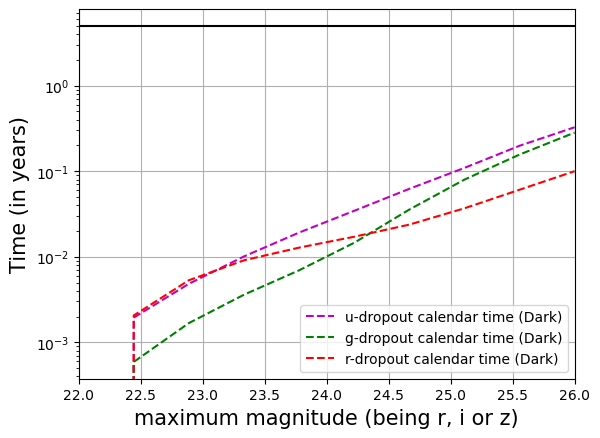

In [20]:
for i, band in enumerate(['u', 'g', 'r']):
    mask = results['band'] == band
    #plt.plot(results['mag_max'][mask], results['fibre_time'][mask], label=f'{band}-dropout fibre time', color=color[i], )
    plt.plot(results['mag_max'][mask], results['calendar_time'][mask], '--', label=f'{band}-dropout calendar time (Dark)', color=color[i])
plt.ylabel('Time (in years)', fontsize=15)
plt.yscale('log')
plt.xlabel('maximum magnitude (being r, i or z)', fontsize=15)
plt.legend()
plt.grid(which='major')
plt.xlim(22, 26)
#plt.ylim(1e-2, 7)
plt.axhline(5, color='k', )
plt.savefig(f'../figures/LBG_survey_time.png', dpi = 300, bbox_inches='tight' )

/tmp/ipykernel_2107558/4114401857.py:6: RuntimeWarning: invalid value encountered in divide
  plt.plot(results['mag_max'][mask], results['tracer_density_spec'][mask]/results['tracer_density'][mask], color=color[i], ls='-')
/tmp/ipykernel_2107558/4114401857.py:7: RuntimeWarning: invalid value encountered in divide
  plt.plot(results['mag_max'][mask], results['tracer_density_spec_one_exp'][mask]/results['tracer_density'][mask], color=color[i], ls='--')
/tmp/ipykernel_2107558/4114401857.py:22: RuntimeWarning: invalid value encountered in divide
  plt.plot(results['mag_max'][mask], results['pass_density'][mask]/results['tracer_density'][mask], label=f'{band}-dropout', color=color[i],)


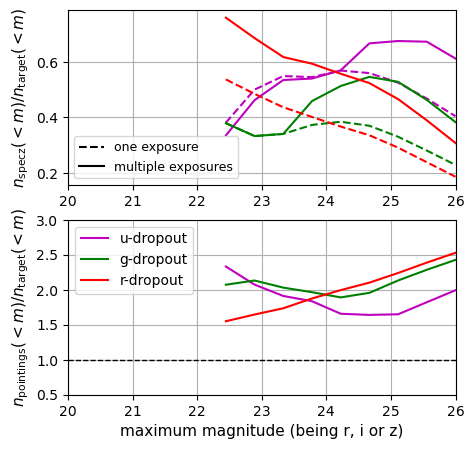

In [11]:
plt.figure(figsize=(5, 5))
plt.subplot(211)
for i, band in enumerate(['u', 'g', 'r']):
    mask = results['band'] == band

    plt.plot(results['mag_max'][mask], results['tracer_density_spec'][mask]/results['tracer_density'][mask], color=color[i], ls='-')
    plt.plot(results['mag_max'][mask], results['tracer_density_spec_one_exp'][mask]/results['tracer_density'][mask], color=color[i], ls='--')
    x = np.sum(samples[i]['object_count'], axis=0)*0.001
    #plt.plot(mag_centers, x/max(x), color=color[i], )

plt.ylabel(r'$n_{\rm specz}(<m)/n_{\rm target}(<m)$', fontsize=11)
plt.plot([], [], '--k', label = 'one exposure')
plt.plot([], [], '-k', label = 'multiple exposures')
plt.legend(loc='lower left', fontsize=9)
plt.grid(which='both')
#plt.yscale('log')
#plt.ylim(0., 1)
plt.xlim(20, 26)
plt.subplot(212)
for i, band in enumerate(['u', 'g', 'r']):
    mask = results['band'] == band
    plt.plot(results['mag_max'][mask], results['pass_density'][mask]/results['tracer_density'][mask], label=f'{band}-dropout', color=color[i],)

    #x = np.sum(samples[i]['object_count'], axis=0)*0.001
    #plt.plot(samples[i]['mag_center'], 3*x/x[-10], color=color[i],ls='-', lw=1)
plt.ylabel(r'$n_{\rm pointings}(<m)/n_{\rm target}(<m)$', fontsize=11)
plt.axhline(1,color='k', lw=1, ls='--')
plt.xlabel('maximum magnitude (being r, i or z)', fontsize=11)
plt.legend()
plt.ylim(0.5, 3)
plt.grid(which='both')
#plt.yscale('log')
plt.xlim(20, 26)
plt.savefig(f'../figures/LBG_survey_design.png', dpi = 300, bbox_inches='tight' )

In [12]:
def E_wst_qso(redshift, mag):
    return 0.70 * (redshift > 0.3) * np.ones(len(mag))

In [13]:
E_wst_qso(0.4,[22, 22, 22])

array([0.7, 0.7, 0.7])

In [14]:
########## LBG ##########
def E_mse_udrop_single_exp(m): 
    return np.maximum((-0.18*m + 4.8), 0)
def E_desi_udrop_single_exp(m): 
    return np.maximum(-0.2*(m-23.5) + 0.75, 0)
    
def E_wst_lbg_dropout(redshift, mag, dropout_band = 'u', reference = 'mse'):

    Dz_ugr = [6, 7, 8] # Mpc

    texp = 1000 #Dark time WST
    SWST=12**2 #Surface of WST mirror
    if reference=='mse':
        tMSE = 1800 #MSE time
        SMSE = 11.25**2
        alpha = np.sqrt(texp * SWST)/np.sqrt(tMSE * SMSE)
    if reference=='desi':
        tDESI= 2*60*60 #Dark time WST
        SDESI = 3.8**2 #Surface of MSE mirror
        alpha = np.sqrt(texp * SWST)/np.sqrt(tDESI * SDESI)
    
    def f(z, k=10): return 1 / (1 + np.exp(-k * (z - 2.5)))
        
    D_zu = Dz_ugr[0]
    if dropout_band == 'u': D_zx = Dz_ugr[0]
    if dropout_band == 'g': D_zx = Dz_ugr[1]
    if dropout_band == 'r': D_zx = Dz_ugr[2]

    ratio = D_zu / D_zx
    shifted_m = mag -5 * np.log10(ratio)

    efficency = (ratio ** 2) * alpha * E_mse_udrop_single_exp(shifted_m) 
    #if dropout_band == 'u':
    efficency *= f(redshift)
    return efficency

def E_wst_lbg_dropout_piecewise_wdassignies(redshift, mag, p_min=0.7, plateau=0.8, dropout_band = 'u', return_magnitudes=False):

    E1 = np.minimum(E_wst_lbg_dropout(redshift, mag, dropout_band=dropout_band), plateau)
    E2 = np.minimum(np.sqrt(2)*E1, plateau)
    E3 = np.minimum(np.sqrt(3)*E1, plateau)

    m1 = mag[np.argmin(np.abs(E1 - p_min))]
    m2 = mag[np.argmin(np.abs(E2 - p_min))]
    m3 = mag[np.argmin(np.abs(E3 - p_min))]

    E = np.zeros(len(mag))
    E[mag <= m1] = E1[mag <= m1]
    E[(mag > m1)*(mag <= m2)] = p_min
    E[(mag > m2)*(mag <= m3)] = p_min
    E[(mag > m3)] = E3[(mag > m3)]
    return E
    
def n_pass_wst_lbg_dropout_piecewise_wdassignies(redshift, mag, p_min=0.7, plateau=0.8, dropout_band='u'):

    E1 = np.minimum(E_wst_lbg_dropout(redshift, mag, dropout_band=dropout_band), plateau)
    E2 = np.minimum(np.sqrt(2)*E1, plateau)
    E3 = np.minimum(np.sqrt(3)*E1, plateau)

    eta_2_unclip = (p_min - E1)*(1 - E1)/(E2 - E1)
    eta_3_unclip = (p_min - E1 - np.clip(eta_2_unclip, 0, 1) * (E2-E1)/(1-E1) ) * (1 - E2)/(E3 - E2)
    eta_2 = np.clip(eta_2_unclip, 0, 1)
    eta_3 = np.clip(eta_3_unclip, 0, 1)

    plt.plot(mag, eta_2_unclip)
    plt.plot(mag, eta_3_unclip)
    
    m1 = mag[np.argmin(np.abs(E1 - p_min))]
    m2 = mag[np.argmin(np.abs(eta_2_unclip - 1))]
    print(m1, m2)
    m3 = 30

    n = np.zeros(len(E1))

    mask_m1 = mag <= m1
    n[mask_m1] = 1  

    mask_m1_m2 = (mag > m1) * (mag <= m2)
    n[mask_m1_m2] = 1 + eta_2[mask_m1_m2] * (1 - E1[mask_m1_m2])

    p2 = (E2 - E1) / (1 - E1)

    mask_m2_m3 = (mag > m2) * (mag <= m3)
    n[mask_m2_m3] = 1 +  eta_2[mask_m2_m3] * (1 - E1[mask_m2_m3]) + eta_3[mask_m2_m3] * (1 - E1[mask_m2_m3]) * ( 1 - p2[mask_m2_m3])


    return n

21.757575757575758 23.757575757575758


/tmp/ipykernel_374181/1491282096.py:60: RuntimeWarning: divide by zero encountered in divide
  eta_2_unclip = (p_min - E1)*(1 - E1)/(E2 - E1)
/tmp/ipykernel_374181/1491282096.py:61: RuntimeWarning: divide by zero encountered in divide
  eta_3_unclip = (p_min - E1 - np.clip(eta_2_unclip, 0, 1) * (E2-E1)/(1-E1) ) * (1 - E2)/(E3 - E2)
/tmp/ipykernel_374181/1491282096.py:61: RuntimeWarning: invalid value encountered in divide
  eta_3_unclip = (p_min - E1 - np.clip(eta_2_unclip, 0, 1) * (E2-E1)/(1-E1) ) * (1 - E2)/(E3 - E2)


(0.0, 1.0)

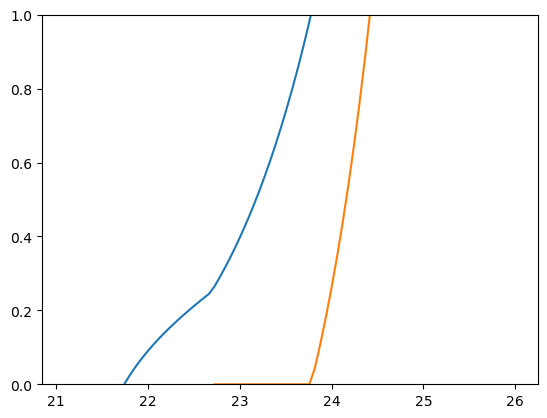

In [35]:
n_pass_wst_lbg_dropout_piecewise_wdassignies(3, np.linspace(20, 26, 100), p_min=0.7, plateau=0.8, dropout_band='u')
plt.ylim(0, 1)